# Gauss-Legendre Quadrature

```22/07/2026```

The main idea of a quadrature rule is to approximate the definite integral of a function over a particular
interval as a sum of the function evaluated over particular points and wheighed by particular factors:


\begin{equation} 
     %\label{eqxx}  
     \int_a^b f(x) \mathrm d x \approx \sum_{k=1}^N w_k f(x_k)
\end{equation}

Usually, a set of points is pre-defined, and a quadrature rule is obtained by imposing that a particular 
choice of wheights will exactly integrate the first $N-1$ polynomials (from the canonycal base 
$\{1, x, x^2, \dots \}$), this incurs in a choice of $N$ particular wheights.

Gaussian quadrature optimizes this procedure by representing a particular (polynomial) function $p(x)$,
of degree $2N-1$ in terms of the $N$-th Legendre polynomial:

\begin{equation} 
     %\label{eqxx} 
     p(x) = q(x) L_N(x) + r(x)  
\end{equation}

where both $q(x)$ and $r(x)$ are $N-1$ degree polynomials. Now, the integral of this function over the interval $(-1, +1)$:

\begin{equation}
     \int_{-1}^{+1} p(x) \mathrm d x = \int_{-1}^{+1} q(x)L_N(x) \mathrm d x + \int_{-1}^{+1} r(x) \mathrm d x 
\end{equation}

The ingenious idea is: the $N$-th Legendre polynomial is **orthogonal** to every degree $N-1$ polynomial. This means
the first term on the right hand side is **zero**, and as such, the integral of the $2N-1$ polynomial over this
interval is numerically the same as the integral of an $N-1$ degree polynomial, meaning we can find $N$ 
optimal wheights to compute it.

Now, which points $x_i \in [-1, +1]$ do we need to chosse to perform this integral numerically? To see that
we must ask ourselves, at which points does $\sum_{k=1}^N w_k q(x_k) L_N(x_k)$ *is guaranteed to be zero*?
The answer is as clear as it is brilliant: the zeros of the $N$-th Legendre polynomial!

It can be shown (albeit dificult) that the special wheights are:

\begin{equation} 
      %\label{eqxx} 
     w_k = \frac{2}{(1-x_k^2)[L_N'(x_k)]^2 }            
\end{equation}

So, just like that, a degree $30$ polynomial is integrated by evaluating it at a mere $16$ points...

In [5]:
import numpy as np
from scipy.special import roots_legendre

# Compute zeros and weights for a 5th-degree Legendre polynomial
N = 5
roots, weights = roots_legendre(N)

print("Roots:", roots)
print("Weights:", weights)


Roots: [-0.90617985 -0.53846931  0.          0.53846931  0.90617985]
Weights: [0.23692689 0.47862867 0.56888889 0.47862867 0.23692689]


In [6]:
# maximum degree of a polynomial integrable by gauss-legendre quadrature
n = 2*N - 1

def p(x, m):
    return x**m

# p's antiderivative
def P(x, m):
    return x**(m+1)/(m+1)

# degree

m = 4

print(f"Exact integral of p(x)=x^{m}: {P(1, m) - P(-1, m)}")

# calculate the quadrature of a degree m polynomial
evaluated_p = np.array([p(x, m) for x in roots])
quad = np.sum(weights*evaluated_p)

print(f"Quadrature of p(x)=x^{m}: {quad}")


Exact integral of p(x)=x^4: 0.4
Quadrature of p(x)=x^4: 0.3999999999999998


In [7]:
# For various degrees

for m in range(0, 2*N-1):
    print(f"Exact integral of p(x)=x^{m}: {P(1, m) - P(-1, m)}")

    # calculate the quadrature of a degree m polynomial
    evaluated_p = np.array([p(x, m) for x in roots])
    quad = np.sum(weights*evaluated_p)

    print(f"Quadrature of p(x)=x^{m}: {quad}")
    print("=="*30)


Exact integral of p(x)=x^0: 2.0
Quadrature of p(x)=x^0: 2.0
Exact integral of p(x)=x^1: 0.0
Quadrature of p(x)=x^1: -2.7755575615628914e-17
Exact integral of p(x)=x^2: 0.6666666666666666
Quadrature of p(x)=x^2: 0.6666666666666665
Exact integral of p(x)=x^3: 0.0
Quadrature of p(x)=x^3: 0.0
Exact integral of p(x)=x^4: 0.4
Quadrature of p(x)=x^4: 0.3999999999999998
Exact integral of p(x)=x^5: 0.0
Quadrature of p(x)=x^5: 0.0
Exact integral of p(x)=x^6: 0.2857142857142857
Quadrature of p(x)=x^6: 0.2857142857142856
Exact integral of p(x)=x^7: 0.0
Quadrature of p(x)=x^7: -1.3877787807814457e-17
Exact integral of p(x)=x^8: 0.2222222222222222
Quadrature of p(x)=x^8: 0.22222222222222207


In [8]:
# If we try to go past 2N-1

m = 2*N

print(f"Exact integral of p(x)=x^{m}: {P(1, m) - P(-1, m)}")

# calculate the quadrature of a degree m polynomial
evaluated_p = np.array([p(x, m) for x in roots])
quad = np.sum(weights*evaluated_p)

print(f"Quadrature of p(x)=x^{m}: {quad}")

# We loose precision

Exact integral of p(x)=x^10: 0.18181818181818182
Quadrature of p(x)=x^10: 0.1788863693625597


In [9]:
# does this work in non-polynomial funcs?

def f(x):
    return np.cos(x)

def F(x):
    #antiderivative
    return np.sin(x)

exact_int = F(1) - F(-1)
print(f"Exact integral of cos(x): {exact_int}")

# calculate the quadrature of cos(x) with 5 points
evaluated_f = np.array([f(x) for x in roots])
quad = np.sum(weights*evaluated_f)

print(f"Quadrature of the cosine: {quad}")

print(f"percentual error: {np.abs((quad-exact_int)/exact_int)*100:1e}%")

#not bad huh?

Exact integral of cos(x): 1.682941969615793
Quadrature of the cosine: 1.6829419704071924
percentual error: 4.702476e-08%


Now let's implement a python function to compute the of a function using this amazing quadrature. A 
robust method should somehow find the optimal number of points to integrate.

In [10]:
# sample function
from emerald.potentials.msc_potential import MsC_potential_vec, MsC_return_points

In [11]:
alpha = 1
E = -0.25
a, b = MsC_return_points(alpha, E)
print(f"Limits of integration: ({a:.3f}, {b:.3f})")



Limits of integration: (-0.882, 3.873)


In [12]:
I = []

for n in range(5, 30):
    roots, weights = roots_legendre(n)

    # cast to [-1, +1] interval
    zetas = ((b-a)/2)*roots + (a+b)/2
    evals = MsC_potential_vec(alpha, zetas)
    quad = ((b-a)/2)*np.sum(weights*evals)

    print(f"GL quadrature of MsC potential with {n:2d} points: I = {quad}")
    I.append(quad)

GL quadrature of MsC potential with  5 points: I = -2.7637146112623596
GL quadrature of MsC potential with  6 points: I = -2.754441933496982
GL quadrature of MsC potential with  7 points: I = -2.7581221526004085
GL quadrature of MsC potential with  8 points: I = -2.7587567045324546
GL quadrature of MsC potential with  9 points: I = -2.757350456882943
GL quadrature of MsC potential with 10 points: I = -2.7577322544713643
GL quadrature of MsC potential with 11 points: I = -2.7580833873584125
GL quadrature of MsC potential with 12 points: I = -2.757837045013547
GL quadrature of MsC potential with 13 points: I = -2.757741518608958
GL quadrature of MsC potential with 14 points: I = -2.7578985259127604
GL quadrature of MsC potential with 15 points: I = -2.757894678093468
GL quadrature of MsC potential with 16 points: I = -2.757810225640456
GL quadrature of MsC potential with 17 points: I = -2.757841870566539
GL quadrature of MsC potential with 18 points: I = -2.7578792015298483
GL quadrature

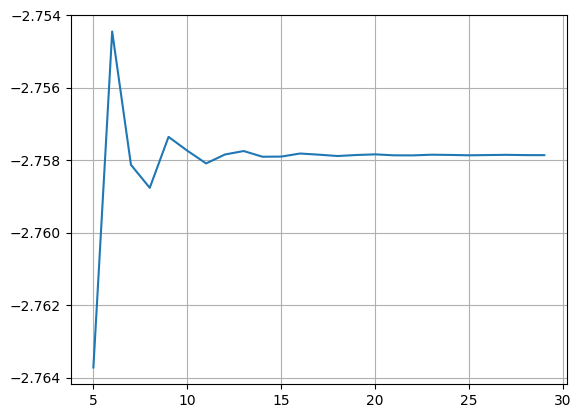

In [13]:
import matplotlib.pyplot as plt
plt.plot(list(range(5, 30)), I)
plt.grid()
plt.show()

In [33]:
I = np.array(I)

In [34]:
dI = np.diff(I)

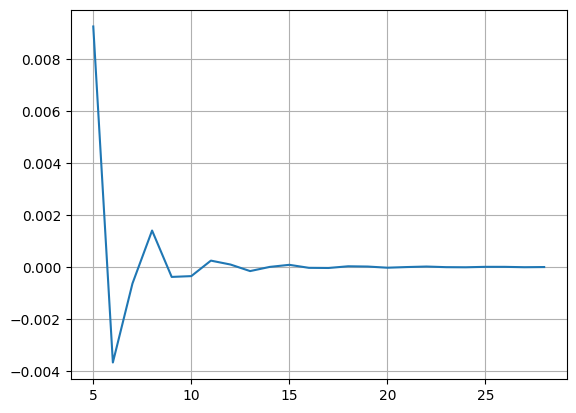

In [36]:
import matplotlib.pyplot as plt
plt.plot(list(range(5, 29)), dI)
plt.grid()
plt.show()

In [37]:
dI[-1]

-1.0857451577805932e-06

Another approach: choose a base resolution, figure out how many points would be needed, then use $N = \dfrac{m + 1}{2}$ ponits

In [51]:
print(f"Interval extension: {b-a:.3f}")
# resolution
r = 0.1

m = int((b-a)/r)
print(f"Supposed number of points needed: {m}")
N = (m+1)//2
print(f"Number of Gauss-Legendre points: {N}")

roots, weights = roots_legendre(N)
# cast to [-1, +1] interval
zetas = ((b-a)/2)*roots + (a+b)/2
evals = MsC_potential_vec(alpha, zetas)
quad1 = ((b-a)/2)*np.sum(weights*evals)

print(f"GL quadrature of MsC potential with {N:2d} points: I = {quad1}")

# Exact(ish) integral
m = 100
roots, weights = roots_legendre(m)
# cast to [-1, +1] interval
zetas = ((b-a)/2)*roots + (a+b)/2
evals = MsC_potential_vec(alpha, zetas)
quad2 = ((b-a)/2)*np.sum(weights*evals)

print(f"GL quadrature of MsC potential with {m:2d} points: I = {quad2}")
print(f"percentual error: {np.abs(quad1-quad2)/quad2*100:.3e}%")

Interval extension: 4.755
Supposed number of points needed: 47
Number of Gauss-Legendre points: 24
GL quadrature of MsC potential with 24 points: I = -2.757848750633093
GL quadrature of MsC potential with 100 points: I = -2.7578518584806795
percentual error: -1.127e-04%


In [45]:
import timeit

In [50]:
m = 100
def run_quadrature():
    roots, weights = roots_legendre(m)
    zetas = ((b - a) / 2) * roots + (a + b) / 2
    evals = MsC_potential_vec(alpha, zetas)
    quad = ((b - a) / 2) * np.sum(weights * evals)
    return quad

# 3. Time the function directly (No strings required!)
# Note: Use a smaller 'number' since loops happen in pure Python here
times = timeit.repeat(run_quadrature, repeat=5,number=2000)
print(f"All runs: {[time/2000 for time in times]}")

All runs: [0.000529068798499793, 0.0005048835709999366, 0.0004974982204998923, 0.0005019413630002418, 0.000497233060000326]


In [ ]:
def gauss_legendre_quadrature(f, a: float, b: float, max_points: int = None):
    """
    Gauss-Legendre quadrature to integrate f(x) over the interval [a, b]
    """

    